In [1]:
# Runtime evidence: this cell checks the environment actually used by the kernel.
import sys as _shape_sys, json as _shape_json, importlib.util as _shape_util
print("SHAPE_RUNTIME_PROVENANCE=" + _shape_json.dumps({
    "python_executable": _shape_sys.executable,
    "python_version": _shape_sys.version.split()[0],
    "shape_lab_origin": _shape_util.find_spec("shape_lab").origin
}))
del _shape_sys, _shape_json, _shape_util


SHAPE_RUNTIME_PROVENANCE={"python_executable": "/opt/pyvenv/bin/python", "python_version": "3.13.5", "shape_lab_origin": "/tmp/shape-course-q90rdcpz/course/src/shape_lab/__init__.py"}


# Stage 24 — Symplectic integration, energy, phase and long rollouts

Manufactured oscillator trajectories with exact reference; a measured sunspot delay cloud used as a negative control against invented energy claims.

This is an executed reference, not a learner assessment. Read the lesson and predict the results before running. All code is inspectable in `src/shape_lab/physics`. No model or dataset downloads occur.

In [2]:
from IPython import get_ipython
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib','inline')
STAGE=24
from pathlib import Path
import sys, json, hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
ROOT=Path.cwd()
while not (ROOT/'pyproject.toml').exists() and ROOT.parent!=ROOT:ROOT=ROOT.parent
if not (ROOT/'pyproject.toml').exists():raise RuntimeError('Open this notebook within the extracted project.')
sys.path.insert(0,str(ROOT/'src'))
from shape_lab.physics import classical as c, constraints as con, gradients as grad, operators as op
hahn=pd.read_csv(ROOT/'data/physics/hahn1_excerpt.csv')
hahn_manifest=json.loads((ROOT/'data/physics/manifest.json').read_text())
OUT=ROOT/'physics/reports'/f'{STAGE:02d}'
OUT.mkdir(parents=True,exist_ok=True)
def save_report(result):
    result={'stage':STAGE,'role':'executed teaching experiment; not learner assessment',**result}
    result['source_review_date']='2026-09-20'
    (OUT/'results.json').write_text(json.dumps(result,indent=2,allow_nan=False)+'\n')
    print(json.dumps(result,indent=2))
def finish_figure(name):
    plt.tight_layout();plt.savefig(OUT/f'{name}.png',dpi=140,bbox_inches='tight');plt.show();plt.close()
print('Course:', ROOT.name, '| stage:', STAGE)


Course: course | stage: 24


## The exact counterexample
Do the arithmetic manually: a symplectic step can change the original oscillator energy.

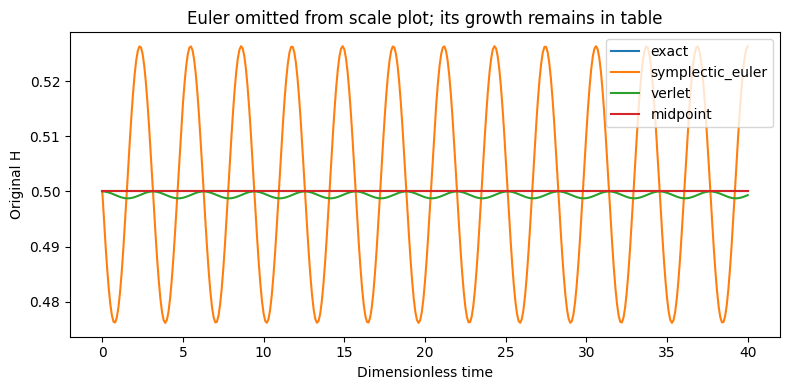

,method,energy_max_abs_error,final_state_error,symplectic_defect
0,exact,2.209344e-14,0.000000,9.162587e-18
1,euler,2.626206e+01,6.326169,1.414214e-02
2,symplectic_euler,2.631316e-02,0.050151,5.551115e-20
3,verlet,1.249928e-03,0.017316,5.663316e-18
4,midpoint,1.487699e-14,0.033282,7.851575e-18


In [3]:
M=c.oscillator_matrix(.2,'symplectic_euler');z=M@np.array([1.,0.])
assert c.symplectic_defect(M)<1e-12
assert abs(float(c.energy(z))-.4808)<1e-12
methods=['exact','euler','symplectic_euler','verlet','midpoint'];rows=[]
plt.figure(figsize=(8,4))
for method in methods:
    Z=c.oscillator_rollout([1.,0.],.1,400,method)
    exact=c.oscillator_rollout([1.,0.],.1,400,'exact')
    E=c.energy(Z)
    rows.append({'method':method,'energy_max_abs_error':float(np.max(abs(E-.5))),'final_state_error':float(np.linalg.norm(Z[-1]-exact[-1])),'symplectic_defect':c.symplectic_defect(c.oscillator_matrix(.1,method))})
    if method!='euler':plt.plot(np.arange(401)*.1,E,label=method)
plt.xlabel('Dimensionless time');plt.ylabel('Original H');plt.title('Euler omitted from scale plot; its growth remains in table');plt.legend();finish_figure('energy')
display(pd.DataFrame(rows))

## A measured loop-like representation is not canonical phase space
The historical annual sunspot snapshot is real; its delay coordinates do not justify interpreting radius as energy.

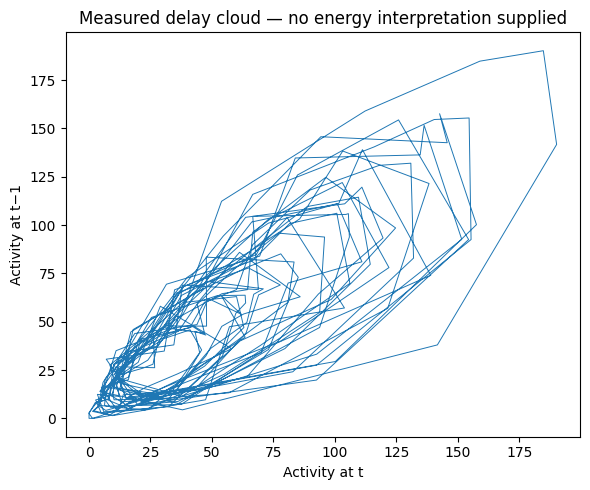

{
  "stage": 24,
  "role": "executed teaching experiment; not learner assessment",
  "data_kind": "manufactured integrator comparison plus observed time-series representation",
  "one_step_energy": 0.4808,
  "one_step_symplectic_defect": 4.44089209850063e-19,
  "methods": [
    {
      "method": "exact",
      "energy_max_abs_error": 2.2093438190040615e-14,
      "final_state_error": 0.0,
      "symplectic_defect": 9.162587281197119e-18
    },
    {
      "method": "euler",
      "energy_max_abs_error": 26.2620586041472,
      "final_state_error": 6.3261687416442856,
      "symplectic_defect": 0.014142135623730963
    },
    {
      "method": "symplectic_euler",
      "energy_max_abs_error": 0.026313157408584864,
      "final_state_error": 0.05015085809068057,
      "symplectic_defect": 5.551115123125788e-20
    },
    {
      "method": "verlet",
      "energy_max_abs_error": 0.0012499278017941706,
      "final_state_error": 0.017316446361532727,
      "symplectic_defect": 5.6633156632

In [4]:
solar=pd.read_csv(ROOT/'data/time_series/sunspots_yearly.csv');s=solar.SUNACTIVITY.to_numpy()
cloud=np.column_stack([s[1:],s[:-1]])
plt.figure(figsize=(6,5));plt.plot(cloud[:,0],cloud[:,1],linewidth=.7);plt.xlabel('Activity at t');plt.ylabel('Activity at t−1');plt.title('Measured delay cloud — no energy interpretation supplied');finish_figure('solar_delay')
from shape_lab.persistence import rips_filtration,persistent_homology
angle=np.arange(24)*2*np.pi/24;circle=np.column_stack([np.cos(angle),np.sin(angle)])
loops=[v for v in persistent_homology(rips_filtration(circle)) if v.dim==1]
assert any(v.lifetime>1 for v in loops)
save_report({'data_kind':'manufactured integrator comparison plus observed time-series representation','one_step_energy':float(c.energy(z)),'one_step_symplectic_defect':c.symplectic_defect(M),'methods':rows,'solar_delay_points':len(cloud),'manufactured_circle_longest_H1':float(max(v.lifetime for v in loops)),'unsupported':'A loop is not a canonical state, measured energy, or proof of correct phase.'})

## Independent explanation

Write the data origin, one supported conclusion and one unsupported conclusion. Change one parameter while preserving the comparison horizon or unit. Save your answer separately; successful reference execution is not proof that you understand the result.